# Crop Recommendation System using Neural Networks

This notebook builds a crop recommendation model using a simple feedforward neural network (TensorFlow/Keras). Given soil and weather conditions, the model recommends the most suitable crop to grow.

**Dataset features:**
- `Nitrogen`, `Phosphorus`, `Potassium` — soil nutrient ratios
- `Temperature` (°C)
- `Humidity` (%)
- `pH_Value` — soil pH
- `Rainfall` (mm)

**Target:** `Crop` — one of 22 crop classes

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Load and Explore the Dataset

In [4]:
# Load dataset — place 'Crop_Recommendation.csv' in the same directory as this notebook
data = pd.read_csv('Crop_Recommendation.csv')
data.columns = data.columns.str.strip()

print("Shape:", data.shape)
data.head()

Shape: (2200, 8)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [5]:
print("Columns:", list(data.columns))
print("\nMissing values:")
print(data.isnull().sum())
print("\nClass distribution:")
print(data['Crop'].value_counts())

Columns: ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall', 'Crop']

Missing values:
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

Class distribution:
Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64


In [8]:
data.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 3. Preprocessing

In [6]:
# Separate features and target
X = data.drop('Crop', axis=1).values
y = data['Crop'].values

# Encode crop labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print("Number of crop classes:", num_classes)
print("Classes:", list(le.classes_))

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Number of crop classes: 22
Classes: ['Apple', 'Banana', 'Blackgram', 'ChickPea', 'Coconut', 'Coffee', 'Cotton', 'Grapes', 'Jute', 'KidneyBeans', 'Lentil', 'Maize', 'Mango', 'MothBeans', 'MungBean', 'Muskmelon', 'Orange', 'Papaya', 'PigeonPeas', 'Pomegranate', 'Rice', 'Watermelon']
Training samples: 1760, Test samples: 440


## 4. Build the Neural Network

In [7]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,086 (47.21 KB)

 Trainable params: 12,086 (47.21 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1919 - loss: 2.8443 - val_accuracy: 0.3352 - val_loss: 2.4024
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3826 - loss: 2.0598 - val_accuracy: 0.5852 - val_loss: 1.3614
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6307 - loss: 1.1892 - val_accuracy: 0.8125 - val_loss: 0.6970
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7273 - loss: 0.8051 - val_accuracy: 0.8864 - val_loss: 0.4556
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7803 - loss: 0.6355 - val_accuracy: 0.8466 - val_loss: 0.3873
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7910 - loss: 0.5411 - val_accuracy: 0.9091 - val_loss: 0.2946
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8239 - loss: 0.4733 - val_accuracy: 0.9091 - val_loss: 0.2682
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8422 - loss: 0.4193 - val_accuracy: 0.9318 - val_loss:

## 6. Evaluate the Model

In [10]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss:     0.0582
Test Accuracy: 0.9818 (98.18%)


In [11]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       0.91      1.00      0.95        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.90      0.95      0.93        20
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       1.00      0.95      0.97        20
       Maize       1.00      0.90      0.95        20
       Mango       0.95      1.00      0.98        20
   MothBeans       0.95      0.95      0.95        20
    MungBean       1.00      1.00      1.00        20
   Muskmelon       0.95      1.00      0.98        20
      Orange       1.00      1.00      1.0

## 7. Training History Plots

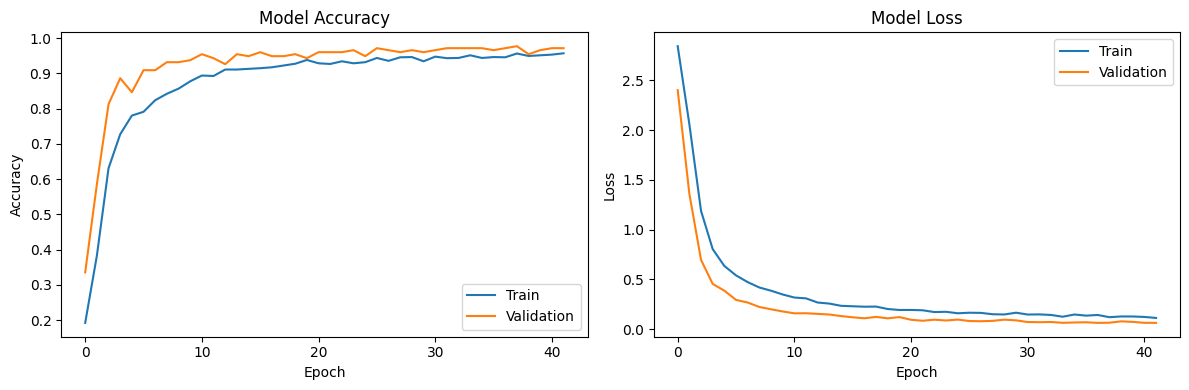

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## 8. Make a Prediction

In [13]:
# Example: Nitrogen=90, Phosphorus=40, Potassium=40,
#          Temperature=25°C, Humidity=80%, pH=6.5, Rainfall=200mm
sample = np.array([[90, 40, 40, 25.0, 80.0, 6.5, 200.0]])
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
recommended_crop = le.inverse_transform([np.argmax(prediction)])[0]
confidence = float(np.max(prediction)) * 100

print(f"Recommended Crop : {recommended_crop}")
print(f"Confidence       : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Recommended Crop : Rice
Confidence       : 52.76%
